# Day 13: Custom Sports Visualization Library

**Phase 1: Foundations & Infrastructure**

## Objective
Develop a robust, reusable, and aesthetically premium sports visualization library for both Football (Soccer) and NFL (American Football) with consistent styling, dual-theme support (Dark/Light), and robust coordinate mapping.

## Task
- [x] **Premium Theme System:** Designed a cohesive visual language with dark/light themes (`THEMES` dictionary) utilizing modern desaturated field colors and vibrant high-contrast accents (Neon Cyan, Pink Magenta, Sapphire Blue) for player tracking, shots, and passes.
- [x] **Football Canvas (`src/viz/pitch.py`):** Developed a modular wrapper using `mplsoccer` that supports horizontal/vertical orientations, multi-theme layouts, and seamless integration with existing matplotlib subplots (`ax` parameter).
- [x] **Shot & Event Mapping (`plot_shots`):** Implemented high-fidelity shot plots scaling marker sizes quadratically based on Expected Goals (xG) and coloring goals vs. non-goals cleanly.
- [x] **Pass Vectorization (`plot_passes`):** Created vector plotting functions with variable alphas (`alpha=0.2` for regular passes, `alpha=0.8` for progressive passes) to systematically eliminate the 'Spaghetti Plot' noise.
- [x] **Heatmap Density (`plot_heatmap`):** Configured 2D Kernel Density Estimation (KDE) tactical heatmaps representing overall player actions/density.
- [x] **NFL Gridiron Rendering (`src/viz/field.py`):** Engineered an exact 120 x 53.3-yard NFL field completely from scratch using `matplotlib.patches`, detailing endzones, yard lines, hashes, and 180° rotatable sidelines numbers.
- [x] **NFL Route Tracking (`plot_play`):** Created a visual tracer plotting continuous trajectories of receivers and a dashed path for the football.
- [x] **System Pipeline Refactoring:** 
  - Dynamically resolved hardcoded macOS paths in `loaders.py` to be fully cross-platform (Windows & macOS relative path bindings).
  - Fixed the local cache loader (`_check_local_cache`) to seamlessly read Parquet files alongside CSV formats.
- [x] **Small Multiples Gallery:** Completed a beautiful 1x3 tactical report in this notebook using real StatsBomb events from the 2022 World Cup, visualizing Heatmaps, Progressive Passes, and Shot xG in a clean grid.

**Deliverable:** Complete sports visualization module with 6+ modular functions + Jupyter demo gallery using real StatsBomb & simulated NFL verse play tracking data.


In [1]:
# Start working here...
import sys
import os
import pandas as pd
import matplotlib.pyplot as plt

sys.path.append(os.path.abspath("../../"))

from src.data.loaders import load_statsbomb_events
from src.viz.pitch import draw_pitch, plot_shots, plot_passes, plot_heatmap

print("Cargando datos de StatsBomb (Mundial 2022)...")
events_df = load_statsbomb_events(competition_id=43, season_id=106)
# Test in the firtst game 
match_id = events_df['match_id'].iloc[0]
match_events = events_df[events_df['match_id'] == match_id].copy()
print(f"Graficando el partido con ID: {match_id}")

# ---------------------------------------------------------


2026-05-17 11:22:24 - INFO - Local cache found. Loading data from: c:\Users\david\Desktop\David\Documentos\David\GitHub\100-days-Data-Sports-Challenge\data\raw/statsbomb/sb_events_43_106.parquet


Cargando datos de StatsBomb (Mundial 2022)...
Graficando el partido con ID: 3857256


2026-05-17 11:23:43 - INFO - Local cache found. Loading data from: c:\Users\david\Desktop\David\Documentos\David\GitHub\100-days-Data-Sports-Challenge\data\raw/statsbomb/sb_events_43_106.parquet


Loading StatsBomb data (World Cup 2022)...
Preparing master tactical report for team: Serbia


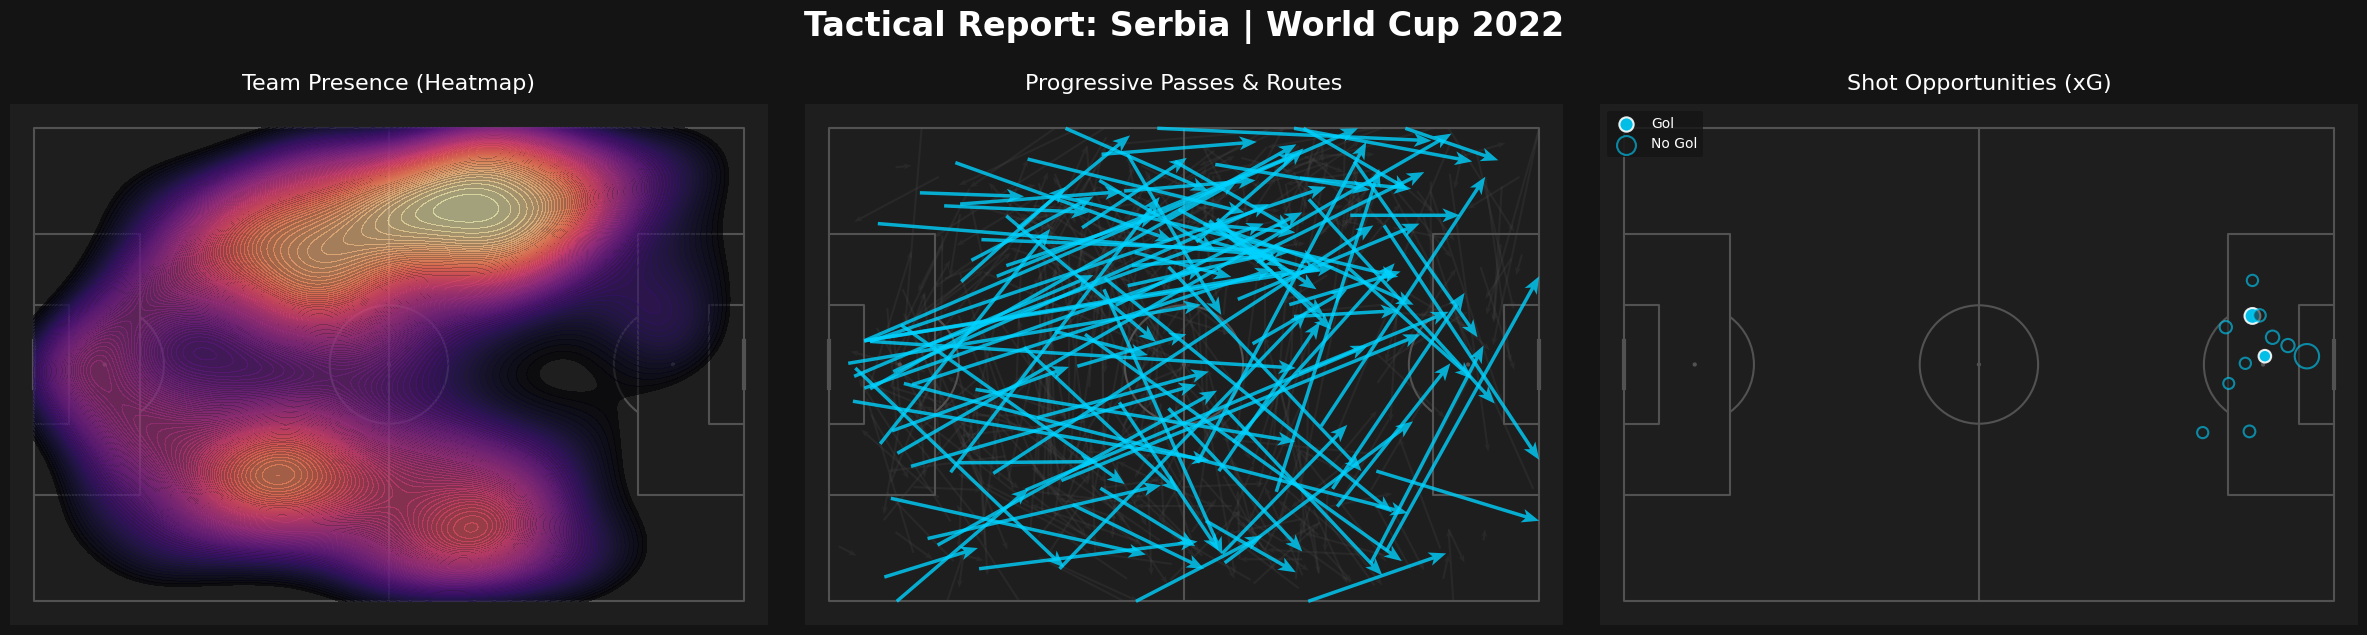

In [3]:
import sys
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 1. Add the project root to the python path so it detects our custom modules
sys.path.append(os.path.abspath("../../"))

from src.data.loaders import load_statsbomb_events
from src.viz.pitch import draw_pitch, plot_shots, plot_passes, plot_heatmap

print("Loading StatsBomb data (World Cup 2022)...")
events_df = load_statsbomb_events(competition_id=43, season_id=106)

# Extract first match and first team available
match_id = events_df['match_id'].iloc[0]
match_events = events_df[events_df['match_id'] == match_id].copy()
team_name = match_events['team'].iloc[0]
team_events = match_events[match_events['team'] == team_name].copy()

print(f"Preparing master tactical report for team: {team_name}")

# 2. ROBUST COORDINATE EXTRACTION (Handles Parquet arrays, lists, and nulls)
def extract_coords(val):
    try:
        return float(val[0]), float(val[1])
    except Exception:
        return np.nan, np.nan

# Extract coordinates using fast apply and list conversion
coords = pd.DataFrame(team_events['location'].apply(extract_coords).tolist(), index=team_events.index)
team_events['x'] = coords[0]
team_events['y'] = coords[1]

# Extract ending coordinates for passes
if 'pass_end_location' in team_events.columns:
    end_coords = pd.DataFrame(team_events['pass_end_location'].apply(extract_coords).tolist(), index=team_events.index)
    team_events['end_x'] = end_coords[0]
    team_events['end_y'] = end_coords[1]
else:
    team_events['end_x'] = np.nan
    team_events['end_y'] = np.nan

# 3. Prepare specialized dataframes for tactical maps
# Shots & Goals (xG data)
shots = team_events[team_events['type'] == 'Shot'].copy()
if 'shot_statsbomb_xg' in shots.columns:
    shots['xg'] = shots['shot_statsbomb_xg']
shots['is_goal'] = shots['shot_outcome'] == 'Goal'

# Passes (Simulating progressive passes if they advance > 15 yards forward)
passes = team_events[team_events['type'] == 'Pass'].copy()
passes['is_progressive'] = (passes['end_x'] - passes['x']) > 15 

# 4. RENDER THE TACTICAL GALLERY (Small Multiples / Subplots)
THEME = 'dark'  # Switch to 'light' to see the clean, academic theme
title_color = '#ffffff' if THEME == 'dark' else '#1e1e1e'
bg_color = '#141414' if THEME == 'dark' else '#f3f4f6'

# 4.1 Create a wide canvas with 3 subplots (1 row, 3 columns)
fig, axs = plt.subplots(1, 3, figsize=(24, 6))
fig.patch.set_facecolor(bg_color)

# 4.2 Subplot 1: Tactical Heatmap
_, _, pitch_obj1 = draw_pitch(pitch_type='statsbomb', theme=THEME, ax=axs[0])
plot_heatmap(team_events.dropna(subset=['x', 'y']), axs[0], pitch_obj1, theme=THEME)
axs[0].set_title("Team Presence (Heatmap)", color=title_color, fontsize=16, pad=10)


# 4.3 Subplot 2: Progressive Passes
# We capture 'pitch_obj' returned from draw_pitch to draw our vectors/arrows
_, _, pitch_obj = draw_pitch(pitch_type='statsbomb', theme=THEME, ax=axs[1])
plot_passes(passes.dropna(subset=['x', 'y', 'end_x', 'end_y']), axs[1], pitch_obj, theme=THEME)
axs[1].set_title("Progressive Passes & Routes", color=title_color, fontsize=16, pad=10)

# 4.4 Subplot 3: Shot Map & xG
draw_pitch(pitch_type='statsbomb', theme=THEME, ax=axs[2])
plot_shots(shots.dropna(subset=['x', 'y']), axs[2], pitch_obj, theme=THEME)
axs[2].set_title("Shot Opportunities (xG)", color=title_color, fontsize=16, pad=10)

# Centered master report title
fig.suptitle(f"Tactical Report: {team_name} | World Cup 2022", color=title_color, fontsize=24, fontweight='bold', y=1.05)

plt.tight_layout()
plt.show()



2026-05-17 11:29:26 - INFO - Downloading NFL pbp data for years: [2023]


Cargando datos reales de la NFL (Play-by-Play 2023)...
2023 done.
Downcasting floats.


2026-05-17 11:29:30 - INFO - Data successfully saved to c:\Users\david\Desktop\David\Documentos\David\GitHub\100-days-Data-Sports-Challenge\data\raw/nfl/nfl_pbp_2023.parquet



--- Jugada Real Encontrada ---
(1:07) (Shotgun) 15-P.Mahomes pass deep middle to 11-M.Valdes-Scantling to DET 30 for 34 yards (23-J.Jacobs).



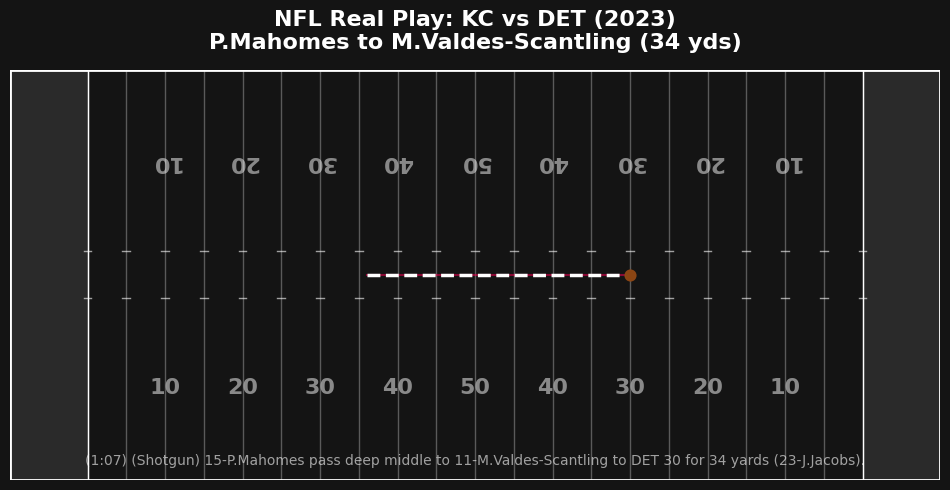

In [4]:
import sys
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

sys.path.append(os.path.abspath("../../"))
from src.data.loaders import load_nfl
from src.viz.field import draw_field, plot_play

print("Cargando datos reales de la NFL (Play-by-Play 2023)...")
pbp_df = load_nfl([2023], data_type="pbp")

# 1. BUSCAR UNA JUGADA REAL
# Filtraremos un pase profundo completo de Patrick Mahomes (KC)
mahomes_plays = pbp_df[
    (pbp_df['passer_player_name'] == 'P.Mahomes') & 
    (pbp_df['play_type'] == 'pass') & 
    (pbp_df['complete_pass'] == 1) & 
    (pbp_df['yards_gained'] > 30)
]

# Tomamos la primera gran jugada que encuentre
real_play = mahomes_plays.iloc[0]
desc = real_play['desc']
print(f"\n--- Jugada Real Encontrada ---\n{desc}\n")

# 2. INGENIERÍA INVERSA: Convertir estadísticas a Coordenadas (X, Y)
# El campo NFL va de X=10 a X=110 (100 yardas de juego)
# 'yardline_100' es la distancia restante hasta la zona de anotación rival.
# Asumimos que la ofensiva ataca de Izquierda a Derecha (hacia X=110).
start_x = 110 - real_play['yardline_100'] 
end_x = start_x + real_play['yards_gained']

# El campo tiene 53.3 yardas de ancho (Y=0 a Y=53.3)
# Mapeamos 'pass_location' ('left', 'middle', 'right') a coordenadas Y
y_map = {'left': 42.0, 'middle': 26.6, 'right': 11.0}
end_y = y_map.get(real_play['pass_location'], 26.6)
start_y = 26.6 # El QB suele iniciar la jugada desde el centro del campo

# 3. CREAR DATOS DE RASTREO (TRACKING) A PARTIR DE LAS COORDENADAS
frames = 30
# Interpolamos puntos intermedios para generar una trayectoria suave
ball_x = np.linspace(start_x, end_x, frames)
ball_y = np.linspace(start_y, end_y, frames)

real_tracking_df = pd.DataFrame({
    'x': ball_x,
    'y': ball_y,
    'team': 'football',  # Para que 'plot_play' lo dibuje como el balón punteado
    'displayName': 'Ball'
})

# Agregamos la ruta del receptor
wr_x = np.linspace(start_x, end_x, frames)
wr_y = np.linspace(end_y, end_y, frames) # Asumimos que corrió recto por su carril
wr_df = pd.DataFrame({
    'x': wr_x,
    'y': wr_y,
    'team': real_play['posteam'],
    'displayName': real_play.get('receiver_player_name', 'Receiver')
})

# Unimos balón y receptor
play_tracking = pd.concat([real_tracking_df, wr_df])

# 4. RENDERIZAR EN EL CAMPO
THEME = 'dark'
fig, ax = draw_field(theme=THEME)

# Nuestra librería dibuja los datos calculados
plot_play(play_tracking, ax, theme=THEME)

# Título descriptivo y profesional
title_color = '#ffffff' if THEME == 'dark' else '#1e1e1e'
title = f"NFL Real Play: {real_play['posteam']} vs {real_play['defteam']} (2023)\n{real_play['passer_player_name']} to {real_play.get('receiver_player_name', 'Receiver')} ({int(real_play['yards_gained'])} yds)"
ax.set_title(title, color=title_color, fontsize=16, pad=15, fontweight='bold')

# Agregamos la descripción real de la jugada al fondo de la gráfica
ax.text(60, 2, desc[:120] + ("..." if len(desc)>120 else ""), color=title_color, fontsize=10, ha='center', alpha=0.6)

plt.show()
